In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import json
import numpy as np
from tensorflow.keras.utils import to_categorical

# Load the dataset
with open('/content/drive/MyDrive/shipsnet.json') as f:
    dataset = json.load(f)

# Extract data and labels
data = np.array(dataset['data']).astype('uint8')
labels = np.array(dataset['labels']).astype('uint8')

# Reshape data to image format
data = data.reshape(-1, 3, 80, 80).transpose(0, 2, 3, 1)

# One-hot encode labels
labels = to_categorical(labels, num_classes=2)

# Split data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# Now you can use X_train and other variables in your code:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# CNN architecture
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(80,80,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dense(2, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Data augmentation
datagen = ImageDataGenerator(horizontal_flip=True, rotation_range=15)
datagen.fit(X_train)

# training code
model.fit(datagen.flow(X_train, y_train, batch_size=16),
          epochs=10,
          validation_data=(X_test, y_test))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 78, 78, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 39, 39, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     2,654,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,673,986 (10.20 MB)

 Trainable params: 2,673,986 (10.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.7484 - loss: 29.5077 - val_accuracy: 0.8800 - val_loss: 0.2487
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.9056 - loss: 0.2559 - val_accuracy: 0.9413 - val_loss: 0.1994
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.9174 - loss: 0.2339 - val_accuracy: 0.9488 - val_loss: 0.1553
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9227 - loss: 0.1938 - val_accuracy: 0.9525 - val_loss: 0.1611
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.9465 - loss: 0.1389 - val_accuracy: 0.9638 - val_loss: 0.1569
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9423 - loss: 0.1693 - val_accuracy: 0.9750 - val_loss: 0.1244
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9558 - loss: 0.1410 - val_accuracy: 0.9600 - val_loss: 0.1358
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.9213 - loss: 0.4009 - val_acc

In [ ]:
history = model.fit(datagen.flow(X_train, y_train, batch_size=16),
                    epochs=10,
                    validation_data=(X_test, y_test))


Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9213 - loss: 0.2634 - val_accuracy: 0.9787 - val_loss: 0.0849
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.9691 - loss: 0.1024 - val_accuracy: 0.9588 - val_loss: 0.1259
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.9657 - loss: 0.1062 - val_accuracy: 0.9825 - val_loss: 0.0690
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9720 - loss: 0.0872 - val_accuracy: 0.9812 - val_loss: 0.0665
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.9709 - loss: 0.0877 - val_accuracy: 0.9837 - val_loss: 0.0569
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9814 - loss: 0.0551 - val_accuracy: 0.9800 - val_loss: 0.0721
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9766 - loss: 0.0793 - val_accuracy: 0.9875 - val_loss: 0.0653
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.9788 - loss: 0.0693 - val_acc

Available keys in history: dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


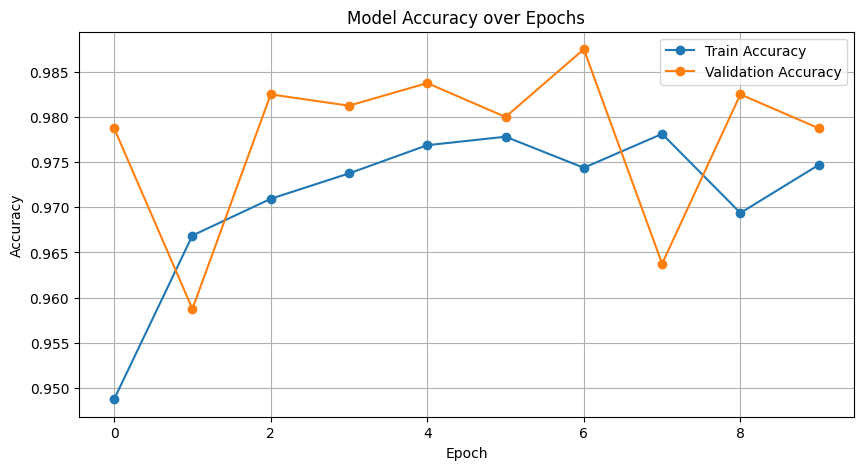

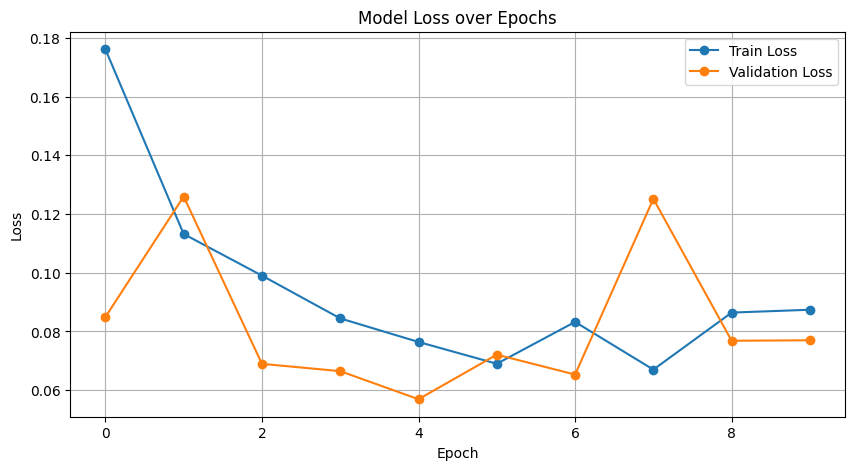

In [ ]:
import matplotlib.pyplot as plt

# Access the history dictionary
hist = history.history

# Debug print keys if needed
print("Available keys in history:", hist.keys())

# Plot Accuracy
plt.figure(figsize=(10, 5))
plt.plot(hist['accuracy'], label='Train Accuracy', marker='o')
plt.plot(hist['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(hist['loss'], label='Train Loss', marker='o')
plt.plot(hist['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9819 - loss: 0.0851
Test Accuracy: 97.87%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


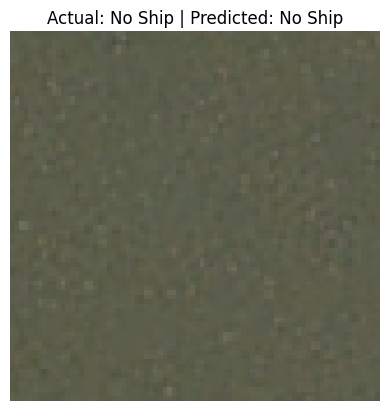

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


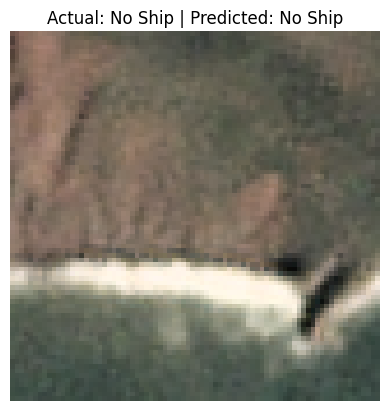

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


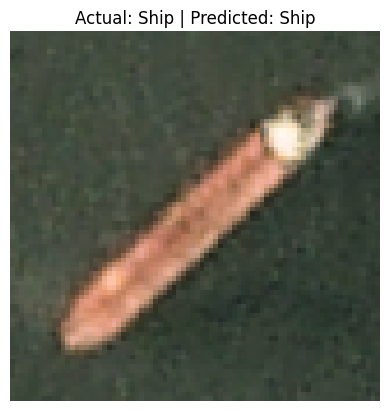

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


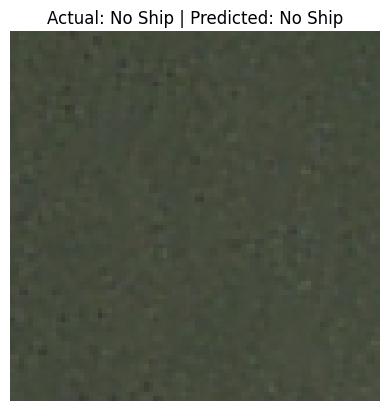

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


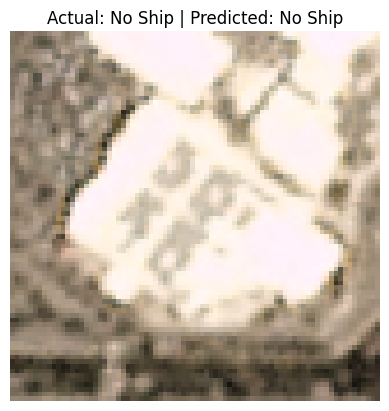

In [ ]:
import matplotlib.pyplot as plt
import random

def predict_and_show(idx):
    img = X_test[idx]
    actual = 'Ship' if np.argmax(y_test[idx]) == 1 else 'No Ship'
    prediction = model.predict(np.expand_dims(img, axis=0))
    predicted = 'Ship' if np.argmax(prediction) == 1 else 'No Ship'

    plt.imshow(img)
    plt.title(f"Actual: {actual} | Predicted: {predicted}")
    plt.axis('off')
    plt.show()

# Show 5 random predictions
for _ in range(5):
    index = random.randint(0, len(X_test) - 1)
    predict_and_show(index)
